# **DATA 6510 Data Warehousing & Visualization**
# **Group Project Part 2: Analyze a Course Data Warehouse**
__B. Pitch Outs__

- Created by Prof. Chris Huntley
- Added/revised by Prof. Kang Lee

##**Steps to Follow**
1. Using the outcomes from Part 2A (i.e., your own questions, SQL queries, and their output), craft compelling stories to anchor your final presentation.
2. Create visualization: design your charts and graphs based on the options provided below.
3. Prepare a 10-minute presentation. Use any presentation software you're comfortable with to create slides.
    - Apply the data visualization principles covered in Lesson 12 to every slide.
    - While telling your stories, share any challenges encountered or lessons learned to help your peers to learn from your experience.
    - Do not include SQL code in your slides.
4. Export your final slides as a PDF (*.pdf) and have the team representative submit the slides to the Classroom assignment by the deadline. You do not need to submit this Notebook you used for visualization.
5. Present your findings during our final class session.
    - Each team has 10 minutes for their presentation. Avoid finishing too early or overstaying your time slot. Time management will be one of the key factors in your evaluation.
    - Unlike Part 1, the team will decide individual roles.
    - All team members must be present and speak for an equal amount of time.
    - The presentation sequence will be randomly determined on the day of the presentation.
    - Your presentation is expected to be professional and informative. Avoid simply reading out text directly from the slide.
    - Be prepare to answer questions from the audience both during and after your presentation.

##**Notes on AI Use**
You are welcome to use AI for this part. However, always ensure that you thoroughly understand the final results.

## **Timeline**
- Part 2A Colab Notebook submission: Mon, 4/27 at 6:30 pm ET (late policy: 20% deduction for every 6-hour delay)
- Part 2B presentation slides submission: Sun, 5/3 at 11:59 pm ET (late policy: 20% deduction for every 6-hour delay)
- In-class presentation: Mon, 5/4

## **Grading**
- Part 2A SQL queries: 7 points
- Part 2B slides: 7 points
- Part 2B presentation: 6 points

##**How to Create Visualization and Export Data from Your Database**

In [1]:
# Load %%sql magic
%pip install jupysql
%load_ext sql
%config SqlMagic.displaylimit = None

# Load duckdb engine for SqlAlchemy
%pip install duckdb-engine --quiet

displaylimit: Value None will be treated as 0 (no limit)

You should have a shortcut to your shared team folder on Google Drive. Refer to the Group Project Part 2A notebook for details.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

folder = "JLN"
data_path = f"/content/drive/My Drive/{folder}/"

import os
os.chdir(data_path)
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/.shortcut-targets-by-id/12OedkaTTI8k7c4AMwtOYivsXMZUR7Fzy/JLN'

In [3]:
# Connect with the CourseDataWarehouse database
%sql duckdb:///CourseDataWarehouse.duckdb

Connecting to 'duckdb:///CourseDataWarehouse.duckdb'

In [4]:
# Check all tables in the database
%sql SELECT * FROM sqlite_master;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

type,name,tbl_name,rootpage,sql
table,CLASS_MEETING_FACTS,CLASS_MEETING_FACTS,0,"CREATE TABLE CLASS_MEETING_FACTS(ClassMeetingFactID INTEGER DEFAULT(nextval('seq_ClassMeetingFactID')) PRIMARY KEY, ProgramID INTEGER, PrimaryInstructorID INTEGER, LocationID INTEGER, CourseOfferingID INTEGER NOT NULL, TimeCodeID INTEGER, TermID INTEGER, ClassDate VARCHAR, FOREIGN KEY (ProgramID) REFERENCES PROGRAMS_DIM(ProgramID), FOREIGN KEY (PrimaryInstructorID) REFERENCES INSTRUCTORS_DIM(InstructorID), FOREIGN KEY (LocationID) REFERENCES LOCATIONS_DIM(LocationID), FOREIGN KEY (CourseOfferingID) REFERENCES COURSE_OFFERINGS_DIM(CourseOfferingID), FOREIGN KEY (TimeCodeID) REFERENCES TIMECODES_DIM(TimeCodeID), FOREIGN KEY (TermID) REFERENCES TERMS_DIM(TermID));"
table,COURSE_OFFERINGS_DIM,COURSE_OFFERINGS_DIM,0,"CREATE TABLE COURSE_OFFERINGS_DIM(CourseOfferingID INTEGER DEFAULT(nextval('seq_CourseOfferingID')) PRIMARY KEY, CRN INTEGER NOT NULL, CourseCode VARCHAR NOT NULL, TermCode VARCHAR NOT NULL, Section VARCHAR NOT NULL, CourseTitle VARCHAR NOT NULL, CreditsTxt VARCHAR, CreditsMin FLOAT, CreditsMax FLOAT, NumStudents INTEGER NOT NULL, CapStudents INTEGER NOT NULL, ScheduleType VARCHAR, ScheduleSpec VARCHAR, DeliveryStyle VARCHAR);"
table,DAYS_OF_WEEK_UTIL,DAYS_OF_WEEK_UTIL,0,"CREATE TABLE DAYS_OF_WEEK_UTIL(DayCode VARCHAR PRIMARY KEY, DayShort VARCHAR NOT NULL, DayLong VARCHAR NOT NULL);"
table,INSTRUCTORS_DIM,INSTRUCTORS_DIM,0,"CREATE TABLE INSTRUCTORS_DIM(InstructorID INTEGER DEFAULT(nextval('seq_InstructorID')) PRIMARY KEY, InstructorName VARCHAR NOT NULL, instructorEmail VARCHAR);"
table,LOCATIONS_DIM,LOCATIONS_DIM,0,"CREATE TABLE LOCATIONS_DIM(LocationID INTEGER DEFAULT(nextval('seq_LocationID')) PRIMARY KEY, LocationCode VARCHAR NOT NULL, Building VARCHAR, Room VARCHAR, Capacity INTEGER DEFAULT(0), SeatsMax INTEGER DEFAULT(0));"
table,PROGRAMS_DIM,PROGRAMS_DIM,0,"CREATE TABLE PROGRAMS_DIM(ProgramID INTEGER DEFAULT(nextval('seq_ProgID')) PRIMARY KEY, ProgramCode VARCHAR NOT NULL, ProgramName VARCHAR NOT NULL, School VARCHAR);"
table,TERMS_DIM,TERMS_DIM,0,"CREATE TABLE TERMS_DIM(TermID INTEGER DEFAULT(nextval('seq_TermID')) PRIMARY KEY, TermCode VARCHAR NOT NULL, TermSeq INTEGER DEFAULT(0), TermName VARCHAR NOT NULL, CalendarYear INTEGER, SchoolYearEnd INTEGER);"
table,TIMECODES_DIM,TIMECODES_DIM,0,"CREATE TABLE TIMECODES_DIM(TimeCodeID INTEGER DEFAULT(nextval('seq_TimeCodeID')) PRIMARY KEY, DayCode VARCHAR NOT NULL, DayNum INTEGER NOT NULL, StartTime TIME, EndTime TIME, DurationMins INTEGER, FOREIGN KEY (DayCode) REFERENCES DAYS_OF_WEEK_UTIL(DayCode));"
table,TIMECODE_SEGMENTS_INTERSECT,TIMECODE_SEGMENTS_INTERSECT,0,"CREATE TABLE TIMECODE_SEGMENTS_INTERSECT(TimeCodeID INTEGER, TimeSegmentID INTEGER, PRIMARY KEY(TimeCodeID, TimeSegmentID), FOREIGN KEY (TimeCodeID) REFERENCES TIMECODES_DIM(TimeCodeID), FOREIGN KEY (TimeSegmentID) REFERENCES TIME_SEGMENTS_UTIL(TimeSegmentID));"
table,TIME_SEGMENTS_UTIL,TIME_SEGMENTS_UTIL,0,"CREATE TABLE TIME_SEGMENTS_UTIL(TimeSegmentID INTEGER DEFAULT(nextval('seq_TimeSegmentID')) PRIMARY KEY, StartSegTime TIME NOT NULL, EndSegTime TIME NOT NULL);"


**Q**: What are the top 10 courses with the highest enrollment?

In [5]:
%%sql
SELECT CourseTitle, SUM(NumStudents) AS TotalEnrollment
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
GROUP BY CourseTitle
ORDER BY TotalEnrollment DESC
LIMIT 10;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

CourseTitle,TotalEnrollment
Introduction to Philosophy,250855
Origins of the Modern World Since 1500,185757
Applied Calculus I,170525
Introduction to Microeconomics,143992
Texts and Contexts II: Writing About Literature,135271
Introduction to Financial Accounting,133930
Introduction to Macroeconomics,128633
Texts and Contexts I: Writing as Craft and Inquiry,124103
Introduction to Management Accounting,123760
Principles of Marketing,118992


In [6]:
rs = %sql SELECT CourseTitle, SUM(NumStudents) AS TotalEnrollment FROM CLASS_MEETING_FACTS JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID) GROUP BY CourseTitle ORDER BY TotalEnrollment DESC

df = rs.DataFrame()
df

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,CourseTitle,TotalEnrollment
0,Introduction to Philosophy,250855.0
1,Origins of the Modern World Since 1500,185757.0
2,Applied Calculus I,170525.0
3,Introduction to Microeconomics,143992.0
4,Texts and Contexts II: Writing About Literature,135271.0
...,...,...
2856,Internship/Environment,0.0
2857,"Introduction to the Art History of Asia, Afric...",0.0
2858,Comprehensive Examination in Applied Psychology,0.0
2859,Ind Study:Non-Fiction Part IV,0.0


#### Option 1: Create Visualization in Python

<Axes: title={'center': 'Total Enrollment'}, ylabel='CourseTitle'>

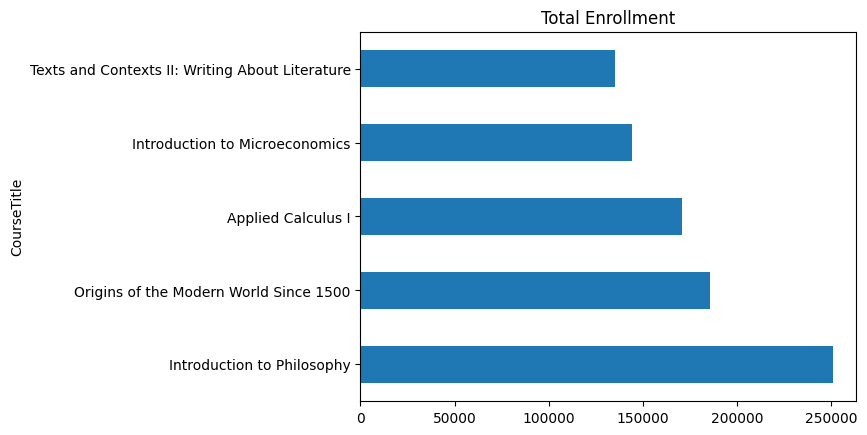

In [7]:
df.set_index('CourseTitle')[:5].plot(kind='barh', title='Total Enrollment', legend=False)

#### Option 2: Export to a CSV File
Most visualization software takes a CSV file as input.

In [8]:
#df.to_csv('data.csv', sep=',', index=False)

#### Option 3: Export to an Excel File
You can use Microsoft Excel for visualization.

In [9]:
#df.to_excel('data.xlsx', index=False)

## **Your Code for Visualization**

JLN University

Our goal: Present the university at a Conference
---
A breakdown of each program
*   School --
*   How many programs are offered?
*   Number of Programs per school
*   Number of Students per program
*   Number of Instructor  per program
*   Most popular course per program
---
Buildings
*   Number of Buildings
*   Most used buildings (most classes)
*   Building Capacity/Max of Seats
---
Classes
*   Class Sizes
*   Popular class by enrollement(Top 10?)
*   Number of classes by term
---
Fun Facts
*   Class Duration
*   Most Common time period for classes(top 10)





















Add as many cells as you need below.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# How many programs per School?
num_prog = %sql SELECT DISTINCT School, COUNT(DISTINCT ProgramName) as NumPrograms FROM PROGRAMS_DIM GROUP BY School ORDER BY NumPrograms DESC

num_prog = pd.DataFrame(num_prog)
num_prog

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,School,NumPrograms
0,CAS,62
1,GED,14
2,DSB,13
3,SOE,12
4,ESN,5


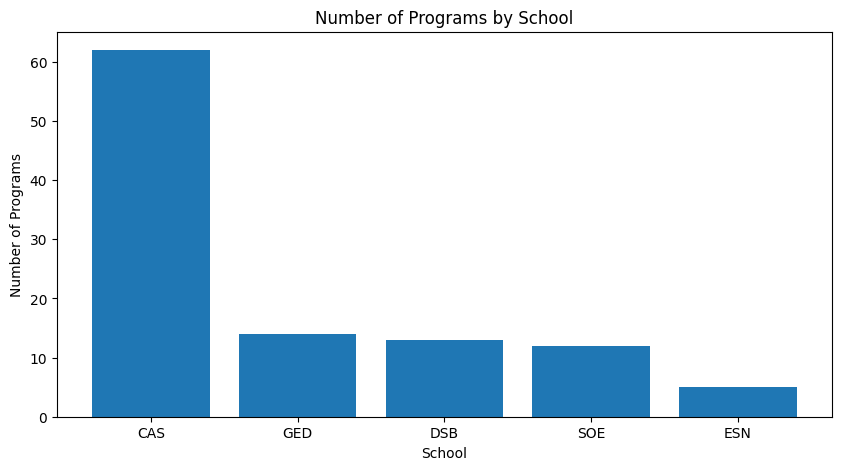

In [12]:
#bar plot
plt.figure(figsize=(10, 5))
plt.bar(num_prog['School'], num_prog['NumPrograms'])
plt.xlabel('School')
plt.ylabel('Number of Programs')
plt.title('Number of Programs by School')
plt.show()

In [13]:
#which school have the highest total student enrollment
student_enro_school = %sql SELECT School, SUM(NumStudents) AS TotalEnrollment FROM PROGRAMS_DIM JOIN CLASS_MEETING_FACTS USING (ProgramID) JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID) GROUP BY School ORDER BY TotalEnrollment DESC

student_enro_school = pd.DataFrame(student_enro_school)
student_enro_school

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,School,TotalEnrollment
0,CAS,6193115
1,DSB,2355681
2,ESN,748873
3,SOE,564445
4,GED,399995


In [14]:
student_enro_school['total'] = student_enro_school['TotalEnrollment'].sum()
student_enro_school

,School,TotalEnrollment,total
0,CAS,6193115,10262109
1,DSB,2355681,10262109
2,ESN,748873,10262109
3,SOE,564445,10262109
4,GED,399995,10262109


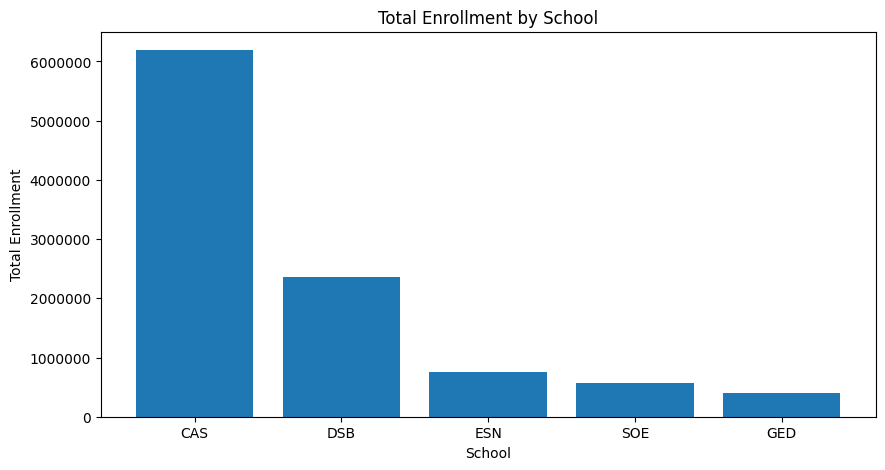

In [15]:
#which school have the highest total student enrollment plot

plt.figure(figsize=(10, 5))
plt.bar(student_enro_school['School'][:5], student_enro_school['TotalEnrollment'][:5])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('School')
plt.ylabel('Total Enrollment')
plt.title('Total Enrollment by School')
plt.show()

In [16]:
#which programs have the highest total student enrollment
student_enro_prog = %sql SELECT ProgramName, SUM(NumStudents) AS TotalEnrollment FROM PROGRAMS_DIM JOIN CLASS_MEETING_FACTS USING (ProgramID) JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID) GROUP BY ProgramName ORDER BY TotalEnrollment DESC

student_enro_prog = pd.DataFrame(student_enro_prog)
student_enro_prog

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,ProgramName,TotalEnrollment
0,Mathematics,855224
1,Nursing,721595
2,Biology,523497
3,Accounting,462972
4,Religious Studies,449243
...,...,...
96,Interdisciplinary,28
97,"Russian, Eastern European, and Central Asian S...",12
98,Liberal and Professional Studies,11
99,Modern Languages & Literature,2


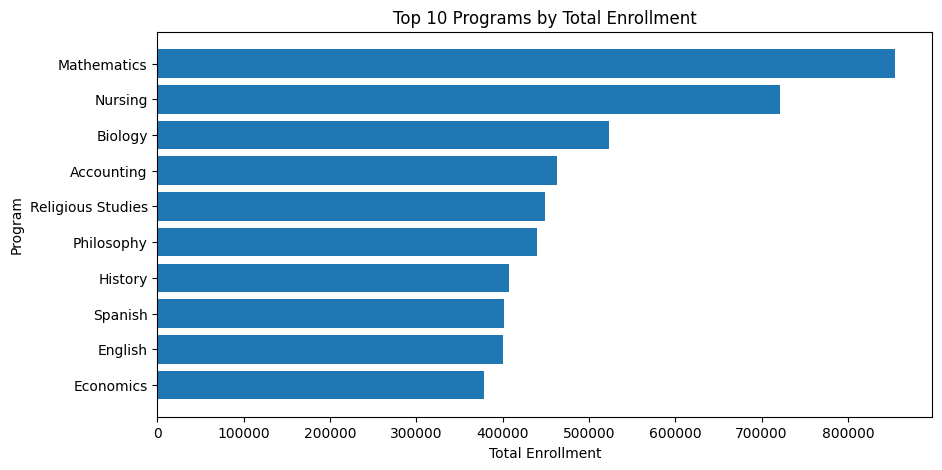

In [17]:
plt.figure(figsize=(10, 5))
plt.barh(student_enro_prog['ProgramName'][:10], student_enro_prog['TotalEnrollment'][:10])
plt.ylabel('Program')
plt.xlabel('Total Enrollment')
plt.title('Top 10 Programs by Total Enrollment')
plt.gca().invert_yaxis()
plt.show()

In [18]:
student_enro_year = %sql SELECT CalendarYear AS Year, SUM(NumStudents) AS TotalEnrollment FROM PROGRAMS_DIM JOIN CLASS_MEETING_FACTS USING (ProgramID) JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID) JOIN TERMS_DIM USING(TermID) GROUP BY Year ORDER BY Year

student_enro_year = pd.DataFrame(student_enro_year)
student_enro_year

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,Year,TotalEnrollment
0,2014,531308
1,2015,1067028
2,2016,1092946
3,2017,1098666
4,2018,1143936
5,2019,1113293
6,2020,1191746
7,2021,1166025
8,2022,1245151
9,2023,612010


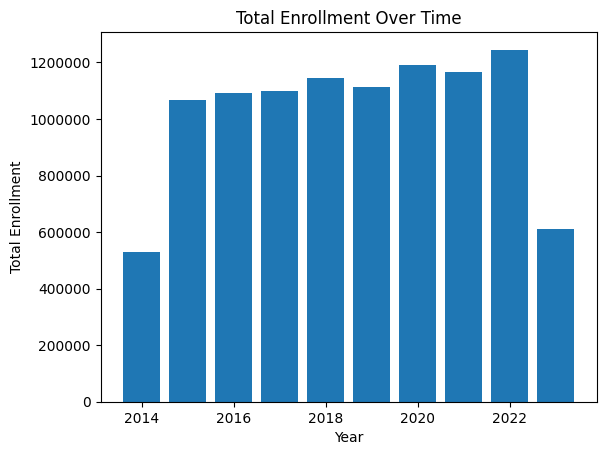

In [19]:
plt.bar(student_enro_year['Year'], student_enro_year['TotalEnrollment'])
plt.xlabel('Year')
plt.ylabel('Total Enrollment')
plt.title("Total Enrollment Over Time")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Section 2 - Louis**

Buildings

Number of Buildings
Most used buildings (most classes)
Building Capacity/Max of Seats



In [20]:
# Buildings most used by year
# Results: not different by year- CNS is by far most popular
%%sql
WITH building_counts AS (
SELECT Building, count(CourseCode) AS NumberOfClasses, CalendarYear
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TERMS_DIM USING (TermID)
  JOIN LOCATIONS_DIM USING (LocationID)
WHERE Building NOT IN ('None')
GROUP BY Building, CalendarYear
ORDER BY count(CourseCode)DESC
),

ranked_buildings AS (
  SELECT
    CalendarYear,
    Building,
    NumberOfClasses,
    RANK() OVER (
      PARTITION BY CalendarYear
      ORDER BY NumberOfClasses DESC
    ) AS BuildingRank
  FROM building_counts
)

SELECT
  CalendarYear,
  Building,
  NumberOfClasses
FROM ranked_buildings
WHERE BuildingRank = 1
ORDER BY CalendarYear DESC;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

CalendarYear,Building,NumberOfClasses
2023,CNS,7467
2022,CNS,8876
2021,CNS,14276
2020,CNS,15056
2019,CNS,15697
2018,CNS,17423
2017,CNS,17158
2016,CNS,17346
2015,CNS,17346
2014,CNS,8889


In [21]:
df = _.DataFrame()

In [22]:
# Most popular building
# Results: not different by year- CNS is by far most popular
%%sql
SELECT Building, count(CourseCode) AS NumberOfClasses
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TERMS_DIM USING (TermID)
  JOIN LOCATIONS_DIM USING (LocationID)
WHERE Building NOT IN ('None') AND CalendarYear = '2023'
GROUP BY Building
ORDER BY count(CourseCode) DESC
Limit 10;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

Building,NumberOfClasses
CNS,7467
BNW,7185
DSBN,6767
NHS,3881
DMH,3026
MCA,918
DSB,486
MCK,235
NYS,200
LYL,192


In [23]:
df = _.DataFrame()

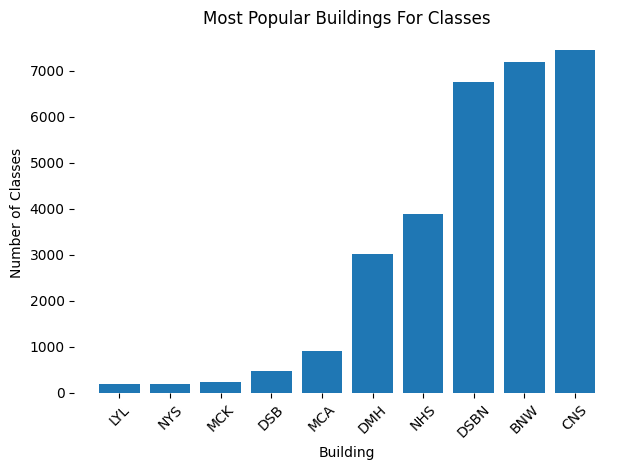

In [24]:
plt.figure()
plt.bar(df["Building"], df["NumberOfClasses"])

plt.xlabel("Building")
plt.ylabel("Number of Classes")
plt.title("Most Popular Buildings For Classes")

plt.xticks(rotation=45)
plt.gca().invert_xaxis()

# remove border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
# Buildings most used by major
# Interesting but which is the most popular buildings now by major
%%sql
WITH building_counts AS (
  SELECT ProgramName, Building, COUNT(ProgramCode) AS NumberOfClasses
  FROM CLASS_MEETING_FACTS
    JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
    JOIN TERMS_DIM USING (TermID)
    JOIN LOCATIONS_DIM USING (LocationID)
    JOIN PROGRAMS_DIM USING (ProgramID)
  WHERE Building NOT IN ('None')
  GROUP BY ProgramName, Building
  ORDER BY NumberOfClasses DESC
  LIMIT 15
),

ranked AS (
  SELECT *, ROW_NUMBER() OVER (
      PARTITION BY ProgramName
      ORDER BY NumberOfClasses DESC
    ) AS rn
  FROM building_counts
)

SELECT ProgramName, Building, NumberOfClasses
FROM ranked
WHERE rn = 1;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

ProgramName,Building,NumberOfClasses
Accounting,DSB,9484
Mechanical Engineering,BNW,7610
Physics,BNW,9704
Biology,BNW,20203
Chemistry,BNW,16589
Spanish,CNS,14370
Finance,DSB,7430
Psychology,BNW,12180
History,CNS,11885
Mathematics,BNW,28296


In [26]:
# Buildings most used by major
# Interesting but which is the most popular buildings now by major
%%sql
  SELECT ProgramName, Building, COUNT(ProgramCode) AS NumberOfClasses
  FROM CLASS_MEETING_FACTS
    JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
    JOIN TERMS_DIM USING (TermID)
    JOIN LOCATIONS_DIM USING (LocationID)
    JOIN PROGRAMS_DIM USING (ProgramID)
  WHERE Building NOT IN ('None')
  GROUP BY ProgramName, Building
  ORDER BY NumberOfClasses DESC
  LIMIT 20;


Running query in 'duckdb:///CourseDataWarehouse.duckdb'

ProgramName,Building,NumberOfClasses
Mathematics,BNW,28296
Biology,BNW,20203
Chemistry,BNW,16589
Nursing,NHS,16265
Spanish,CNS,14370
Psychology,BNW,12180
History,CNS,11885
English,CNS,11881
Philosophy,CNS,11302
Religious Studies,CNS,10257


In [27]:
# Buildings most used by count of major
# As we thought CNS is still the most popular building- but is it the largest?
%%sql
WITH building_counts AS (
  SELECT ProgramName, Building,
    COUNT(ProgramCode) AS NumberOfClasses
  FROM CLASS_MEETING_FACTS
    JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
    JOIN TERMS_DIM USING (TermID)
    JOIN LOCATIONS_DIM USING (LocationID)
    JOIN PROGRAMS_DIM USING (ProgramID)
  WHERE Building NOT IN ('None')
  GROUP BY ProgramName, Building
),

ranked AS (
  SELECT *, ROW_NUMBER() OVER (
      PARTITION BY ProgramName
      ORDER BY NumberOfClasses DESC
    ) AS rn
  FROM building_counts
),

top_buildings AS (
  SELECT ProgramName, Building
  FROM ranked
  WHERE rn = 1
)

SELECT
  Building,
  COUNT(*) AS NumMajors
FROM top_buildings
GROUP BY Building
ORDER BY NumMajors DESC;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

Building,NumMajors
CNS,44
BNW,16
DSB,10
DMH,8
NHS,8
DSBN,2
XVR,2
DLH,1
SWH,1
LYL,1


In [28]:
df = _.DataFrame()

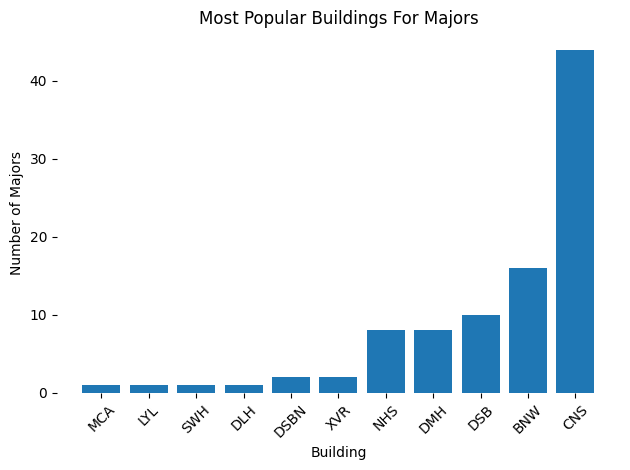

In [29]:
plt.figure()
plt.bar(df["Building"], df["NumMajors"])

plt.xlabel("Building")
plt.ylabel("Number of Majors")
plt.title("Most Popular Buildings For Majors")

plt.xticks(rotation=45)
plt.gca().invert_xaxis()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Largest Building
# CNS remains to be the most popular building and it makes sense that most majors mainly take place here- is it too packed though?
%%sql
SELECT DISTINCT Building, count(capacity) AS BuildingCapacity
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TERMS_DIM USING (TermID)
  JOIN LOCATIONS_DIM USING (LocationID)
WHERE Building NOT IN ('None') AND CalendarYear = ('2021')
GROUP BY Building
ORDER BY count(capacity)DESC;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

Building,BuildingCapacity
CNS,14276
BNW,12876
DSBN,10373
NHS,6861
DMH,4868
MCA,2163
LNG,522
MCK,443
LYL,334
NYS,320


In [31]:
df = _.DataFrame()

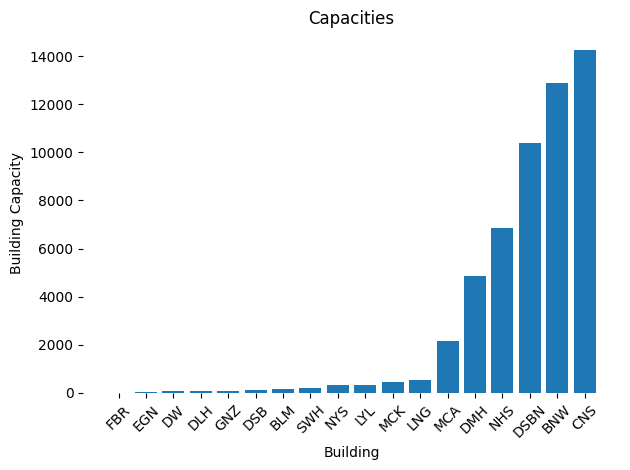

In [32]:
plt.figure()
plt.bar(df["Building"], df["BuildingCapacity"])

plt.xlabel("Building")
plt.ylabel("Building Capacity")
plt.title("Capacities")

plt.xticks(rotation=45)
plt.gca().invert_xaxis()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
# Most utilized building (highest capacity rate)
# This tells is that CNS isnt the worst capacity rate, but whats the average?
%%sql
SELECT Building, SUM(NumStudents) AS EnrolledStudents, SUM(capacity) AS BuildingCapacity, ROUND(SUM(NumStudents) * 100.0 / NULLIF(SUM(capacity),0),2) AS CapacityRate
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TERMS_DIM USING (TermID)
  JOIN LOCATIONS_DIM USING (LocationID)
WHERE Building NOT IN ('None') AND Building IN ('CNS', 'BNW', 'DSB',
'NHS',
'DMH',
'DSBN',
'XVR',
'MCA',
'SWH',
'DLH',
'LYL')
GROUP BY Building
ORDER BY SUM(capacity) DESC, SUM(NumStudents), SUM(NumStudents) / SUM(capacity);

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

Building,EnrolledStudents,BuildingCapacity,CapacityRate
BNW,2235899,4245304,52.67
CNS,2479372,3846581,64.46
NHS,1112331,2144627,51.87
DSB,1017716,1530175,66.51
DSBN,960895,1470492,65.35
DMH,902935,1463332,61.7
MCA,363800,593154,61.33
LYL,70396,113351,62.1
DLH,30602,58050,52.72
XVR,36411,55532,65.57


In [34]:
df = _.DataFrame()

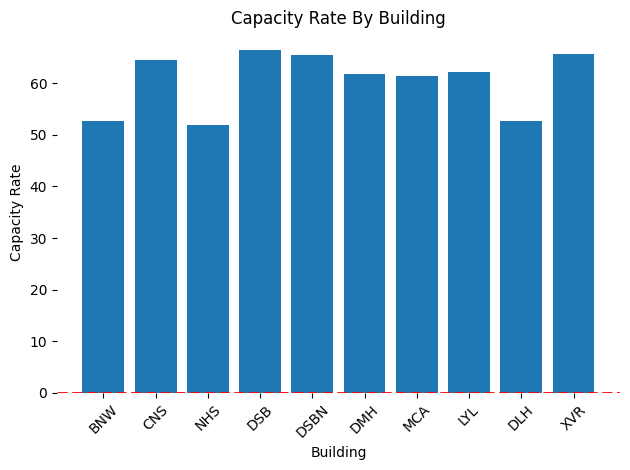

In [35]:
plt.figure()
plt.bar(df["Building"], df["CapacityRate"])

plt.axhline(color='red', linestyle='--', linewidth=2)

plt.xlabel("Building")
plt.ylabel("Capacity Rate")
plt.title("Capacity Rate By Building")

plt.xticks(rotation=45)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# What is the average capacity rate
# CNS is slightly above average capacity rate in 2021, if you want a roomier class maybe consider taking a class in BNW - which is below the average capacity rate typically
%%sql
SELECT SUM(NumStudents) AS EnrolledStudents, SUM(capacity) AS BuildingCapacity, ROUND(AVG(NumStudents) * 100.0 / NULLIF(AVG(capacity),0),2) AS CapacityRate
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TERMS_DIM USING (TermID)
  JOIN LOCATIONS_DIM USING (LocationID)
WHERE Building NOT IN ('None') AND Building IN ('CNS', 'BNW', 'DSB',
'NHS',
'DMH',
'DSBN',
'XVR',
'MCA',
'SWH',
'DLH',
'LYL')
ORDER BY SUM(capacity) DESC, SUM(NumStudents), SUM(NumStudents) / SUM(capacity);

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

EnrolledStudents,BuildingCapacity,CapacityRate
9217483,15520598,59.39


In [37]:
#what is the least popular day of the week for classes by year
%%sql
  SELECT DayLong, count(CourseOfferingID) AS NumClasses, CalendarYear
  FROM CLASS_MEETING_FACTS
    JOIN TIMECODES_DIM USING (TimeCodeID)
    JOIN DAYS_OF_WEEK_UTIL USING (DayCode)
    JOIN TERMS_DIM USING (TermID)
  WHERE DayLong NOT IN ('Saturday', 'Sunday') AND CalendarYear = '2023'
  GROUP BY DayLong, CalendarYear
  Order BY NumClasses DESC;


Running query in 'duckdb:///CourseDataWarehouse.duckdb'

DayLong,NumClasses,CalendarYear
Monday,7560,2023
Wednesday,5968,2023
Thursday,5047,2023
Tuesday,4691,2023
Friday,28,2023


In [38]:
df = _.DataFrame()

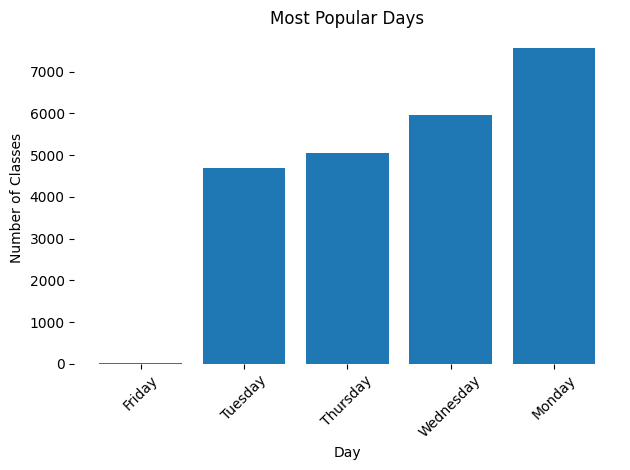

In [39]:
plt.figure()
plt.bar(df["DayLong"], df["NumClasses"])

plt.xlabel("Day")
plt.ylabel("Number of Classes")
plt.title("Most Popular Days")

plt.xticks(rotation=45)
plt.gca().invert_xaxis()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Section 3 - Nick**

Classes


In [40]:
#what are the class sizes across all course offerings
%%sql
SELECT
    CourseOfferingID,
    CourseCode,
    CourseTitle,
    NumStudents AS ClassSize,
    CapStudents AS ClassCapacity
FROM COURSE_OFFERINGS_DIM
ORDER BY NumStudents DESC
LIMIT 10;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

CourseOfferingID,CourseCode,CourseTitle,ClassSize,ClassCapacity
28202,FYEX 1010,Becoming a Successful Student Online,493,600
5120,FYEX 1010,Becoming a Successful Student Online,371,500
28039,ACCT 3990,Live Experience for Online,231,300
28203,FYEX 1010,Becoming a Successful Student Online,171,200
5381,ACCT 3990,Independent Study,159,175
12020,NS 0325C,Medical Surgical Nursing II Clinical,124,0
27398,NS 0305C,Mental Health Nursing Clinical,104,0
3638,BI 0108,Human Anatomy and Physiology II,90,92
17930,NS 0307,Fundamentals of Nursing Care,90,93
10493,BI 0108,Human Anatomy and Physiology II,89,92


In [41]:
result_name = %sql SELECT CourseTitle AS 'Course Title', NumStudents AS 'Class Size', CapStudents AS 'Class Capacity' FROM COURSE_OFFERINGS_DIM ORDER BY NumStudents DESC

result_name_df = result_name.DataFrame()
result_name_df

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,Course Title,Class Size,Class Capacity
0,Becoming a Successful Student Online,493,600
1,Becoming a Successful Student Online,371,500
2,Live Experience for Online,231,300
3,Becoming a Successful Student Online,171,200
4,Independent Study,159,175
...,...,...,...
30758,Medical Surgical Nursing II Clinical,0,14
30759,Independent Study,0,2
30760,Independent Study,0,1
30761,DNP Immersion,-1,1


In [42]:
#what are the top 10 most popular classes by enrollment
#popular_classes
%%sql
SELECT
    CourseOfferingID,
    CourseCode,
    CourseTitle,
    NumStudents AS Enrollment,
    CapStudents AS ClassCapacity
FROM COURSE_OFFERINGS_DIM
ORDER BY NumStudents DESC
LIMIT 10;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

CourseOfferingID,CourseCode,CourseTitle,Enrollment,ClassCapacity
28202,FYEX 1010,Becoming a Successful Student Online,493,600
5120,FYEX 1010,Becoming a Successful Student Online,371,500
28039,ACCT 3990,Live Experience for Online,231,300
28203,FYEX 1010,Becoming a Successful Student Online,171,200
5381,ACCT 3990,Independent Study,159,175
12020,NS 0325C,Medical Surgical Nursing II Clinical,124,0
27398,NS 0305C,Mental Health Nursing Clinical,104,0
3638,BI 0108,Human Anatomy and Physiology II,90,92
17930,NS 0307,Fundamentals of Nursing Care,90,93
10493,BI 0108,Human Anatomy and Physiology II,89,92


In [43]:
popular_classes = %sql SELECT CourseTitle AS 'Course Title', NumStudents AS Enrollment, CapStudents AS 'Class Capacity' FROM COURSE_OFFERINGS_DIM ORDER BY NumStudents DESC LIMIT 10

popular_classes_df = pd.DataFrame(popular_classes)
popular_classes_df = popular_classes_df
popular_classes_df

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,Course Title,Enrollment,Class Capacity
0,Becoming a Successful Student Online,493,600
1,Becoming a Successful Student Online,371,500
2,Live Experience for Online,231,300
3,Becoming a Successful Student Online,171,200
4,Independent Study,159,175
5,Medical Surgical Nursing II Clinical,124,0
6,Mental Health Nursing Clinical,104,0
7,Human Anatomy and Physiology II,90,92
8,Fundamentals of Nursing Care,90,93
9,Human Anatomy and Physiology II,89,92


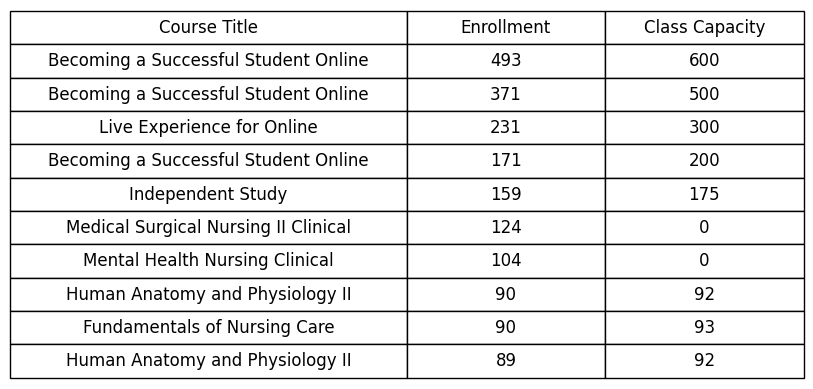

In [44]:
fig, ax = plt.subplots()
ax.axis('off')
table = ax.table(
    cellText=popular_classes_df.values,
    colLabels=popular_classes_df.columns,
    loc='center',
    cellLoc='center',
    colWidths=[0.4, 0.2, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 2)
plt.show()

In [45]:
#which classes have the longest meeting durations
# longest_class_durations <<
%%sql
SELECT DISTINCT CourseTitle CourseTitle,
  CourseOfferingID, CourseCode, DurationMins AS DurationMinutes
FROM CLASS_MEETING_FACTS
  JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID)
  JOIN TIMECODES_DIM USING (TimecodeID)
ORDER BY DurationMins DESC
LIMIT 10;

Running query in 'duckdb:///CourseDataWarehouse.duckdb'

CourseTitle,CourseOfferingID,CourseCode,DurationMinutes
Pediatric Nursing Clinical,5226,NURS 4323C,720
Medical Surgical Nursing II Clinical,12915,NURS 4325C,720
Medical Surgical Nursing II Clinical,20427,NURS 4325C,720
Pediatric Nursing Clinical,5230,NURS 4323C,720
Medical Surgical Nursing II Clinical,12917,NURS 4325C,720
Medical Surgical Nursing II Clinical,28316,NURS 4325C,720
Medical Surgical Nursing II Clinical,20428,NURS 4325C,720
Pediatric Nursing Clinical,12912,NURS 4323C,720
Pediatric Nursing Clinical,5231,NURS 4323C,720
Medical Surgical Nursing II Clinical,20429,NURS 4325C,720


In [46]:
longest_class_durations = %sql SELECT DISTINCT CourseTitle CourseTitle , DurationMins AS 'Duration in Minutes', CourseTitle AS 'Course Title' FROM CLASS_MEETING_FACTS JOIN COURSE_OFFERINGS_DIM USING (CourseOfferingID) JOIN TIMECODES_DIM USING (TimecodeID) ORDER BY DurationMins DESC LIMIT 10

longest_class_durations_df = pd.DataFrame(longest_class_durations)
longest_class_durations_df['Duration in hours'] = longest_class_durations_df['Duration in Minutes'] / 60
longest_class_durations_df


Running query in 'duckdb:///CourseDataWarehouse.duckdb'

,CourseTitle,Duration in Minutes,Course Title,Duration in hours
0,Pediatric Nursing Clinical,720,Pediatric Nursing Clinical,12.000000
1,Maternal and Newborn Nursing Clinical,720,Maternal and Newborn Nursing Clinical,12.000000
2,Transition to Professional Nursing,720,Transition to Professional Nursing,12.000000
3,Medical Surgical Nursing II Clinical,720,Medical Surgical Nursing II Clinical,12.000000
4,Transition to Professional Nursing Clinical,720,Transition to Professional Nursing Clinical,12.000000
5,Pediatric Nursing Clinical,630,Pediatric Nursing Clinical,10.500000
6,Maternal and Newborn Nursing Clinical,630,Maternal and Newborn Nursing Clinical,10.500000
7,Pediatric Nursing Clinical,629,Pediatric Nursing Clinical,10.483333
8,Geriatric Nursing Clinical,600,Geriatric Nursing Clinical,10.000000
9,Mental Health Nursing Clinical,600,Mental Health Nursing Clinical,10.000000


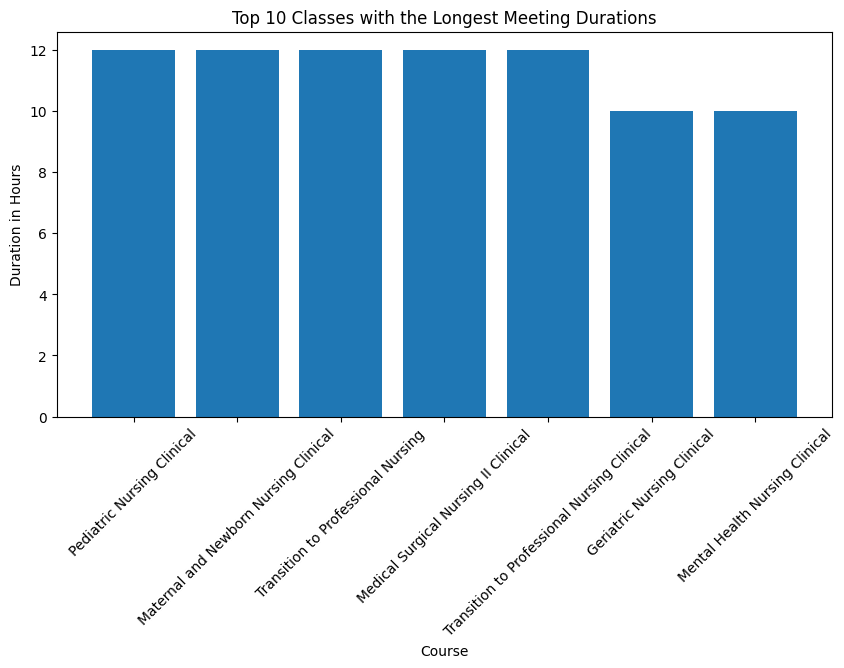

In [47]:

plt.figure(figsize=(10, 5))
plt.bar(longest_class_durations_df['Course Title'], longest_class_durations_df['Duration in hours'])
plt.xlabel('Course')
plt.ylabel('Duration in Hours')
plt.title('Top 10 Classes with the Longest Meeting Durations')
plt.xticks(rotation=45)
plt.show()

---
## **On your way out ... Be sure to Restart Session and Run All and then save.**
Go to `Runtime` > `Restart session and run all`